# Tune $D_{sei}$ to get SEI quality for different formation protocols

2025/04/16

The plan:
1. Define an objective function as some combination of expansion error and voltage error
1. Sweep through different values of D_sei for VC only (just start with VC for now)
1. Plot D_sei vs error function for the three different formation protocols

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from scipy.interpolate import interp1d

%load_ext autoreload

plotter.initialize(plt)

target_dir = os.getcwd()

# Load the Experimental Data

In [2]:
def fetch_file_list(cellid):

    target_dir_arbin = f'{target_dir}/data/raw/from-voltaiq'


    if cellid == 152064:
        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
                        ]

        daq_channel = 'Key_CH1'

        hr_max = 20*24

    elif cellid == 152074: # BASELINE FORMATION (repeat 2)

        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv'
                        ]

        daq_channel = 'Key_CH0'

        hr_max = 20*24

    elif cellid == 152071: # FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH3'

        hr_max = 20*24

    elif cellid == 152098: # SUPER FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMFAST_2_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH2'

        hr_max = 20*24


    return file_arbin_list, daq_channel, hr_max


In [3]:
def fetch_experimental_data(cellid, max_hours=1000000):

    # To make the dQ/dV plot work, be sure to only select the FORM protocol without
    # including the aging file. Otherwise the time vector will be confused.
    file_indices_to_include = np.array([1,2])

    file_arbin_list, daq_channel, hr_max = fetch_file_list(cellid)


    # Load the Arbin Data
    df_arbin_list = []

    for file in np.array(file_arbin_list)[file_indices_to_include]:

        df = pd.read_csv(file)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Timestamp']= df['Timestamp'].apply(lambda x : x.tz_localize(None))
        df_arbin_list.append(df)

    df_arbin = pd.concat(df_arbin_list, axis=0)

    # Filter the Arbin Data
    qq = df_arbin['Charge Capacity (Ah)']
    tv = df_arbin['Timestamp'].astype(int)
    tv = (tv - np.min(tv)) / 1e9
    y_voltage = df_arbin['Potential (V)']
    y_current = df_arbin['Current (A)']

    y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
    y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN

    # Load the Keyence data
    file_keyence = f'{target_dir}/data/raw/from-keyence/keyence_20220901_213928.csv'
    df_keyence = pd.read_csv(file_keyence)
    df_keyence['computer time'] = pd.to_datetime(df_keyence['computer time'], unit='s')
    df_keyence['computer time'] = df_keyence['computer time'].apply(lambda x : x.tz_localize(None))

    # Filter the Keyence data
    df_keyence = df_keyence.loc[(df_keyence['computer time'] > df_arbin['Timestamp'].iloc[0]) & \
                                (df_keyence['computer time'] < df_arbin['Timestamp'].iloc[-1])]
    y_strain = df_keyence[daq_channel] - df_keyence[daq_channel].iloc[0]
    y_strain[y_strain > 500] = np.NaN

    tt = df_keyence['computer time'].astype(int)
    tt = (tt - np.min(tt)) / 1e9

    y_strain.iloc[np.where(tt/3600 > hr_max)] = np.NaN

    out = dict()

    idx = np.where(tv < max_hours*3600)[0]
    out['arbin_time'] = tv.iloc[idx]
    out['arbin_voltage'] = y_voltage.iloc[idx]
    out['arbin_current'] = y_current.iloc[idx]

    idx = np.where(tt < max_hours * 3600)[0]
    out['daq_time'] = tt.iloc[idx]
    out['daq_strain'] = y_strain.iloc[idx]

    return out


# Load the experimental data

In [4]:
expt1 = fetch_experimental_data(152064)
expt2 = fetch_experimental_data(152074)
expt3 = fetch_experimental_data(152071, 16)
expt4 = fetch_experimental_data(152098, 7)

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_81529/704863275.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_81529/704863275.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_81529/704863275.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

In [27]:
def run_sim(type, diff):
    """
    Run simulation for a given formation type and target EC diffusivity

    Arguments:
    ----------
    type: 'base', 'fast', 'fast+'
    diff: target EC diffusivity, e.g., 4.2e-20 [m2/s]

    Returns:
    ----------

    df_sim: DataFrame with simulation results
    """

    cell = cellsim.Cell()
    cell.load_config('params/default.yaml')

    # Update EC diffusivity
    # cell.D_SEI11 = diff
    # cell.D_SEI21 = diff

    # Update VC diffusivity
    cell.D_SEI12 = diff
    cell.D_SEI22 = diff

    if type == 'base':
        sim = cellsim.Simulation(cell, 80*3600)
        sim.run_rest(1, rest_time_hrs=0.5)
        sim.run_chg_cccv(2, 2.5/10, 2.5/20, 4.2)
        sim.run_dch_cccv(2, -2.5/10, -2.5/10, 3.0)
        sim.run_chg_cccv(3, 2.5/10, 2.5/20, 4.2)
        sim.run_dch_cccv(3, -2.5/10, -2.5/10, 3.0)
        sim.run_chg_cccv(4, 2.5/10, 2.5/20, 4.2)
        sim.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
        sim.run_rest(4, rest_time_hrs=6)

    elif type == 'fast':
        sim = cellsim.Simulation(cell, 20*3600)
        sim.run_rest(1, rest_time_hrs=0.5)
        sim.run_chg_cccv(2, 2.5, 2.5, 3.9)
        sim.run_chg_cccv(2, 2.5/5, 0.125, 4.2)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_dch_cccv(2, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_chg_cccv(3, 2.5/5, 0.125, 4.2)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_dch_cccv(3, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_chg_cccv(4, 2.5/5, 0.125, 4.2)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_dch_cccv(4, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_chg_cccv(5, 2.5/5, 0.125, 4.2)
        sim.run_rest(5, rest_time_hrs=1/6)
        sim.run_dch_cccv(5, -2.5/5, 2.5/5, 3.9)
        sim.run_dch_cccv(5, -2.5/1, 0.05, 3.0)
        sim.run_rest(6, rest_time_hrs=3)

    elif type == 'fast+':
        sim = cellsim.Simulation(cell, 10*3600)
        sim.run_rest(1, rest_time_hrs=0.5)
        sim.run_chg_cccv(2, 5.0, 5.0, 3.9)
        sim.run_chg_cccv(2, 2.5, 0.125, 4.2)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_dch_cccv(2, -2.5, 2.5, 3.9)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_chg_cccv(3, 2.5, 0.125, 4.2)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_dch_cccv(3, -2.5, 2.5, 3.9)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_chg_cccv(4, 2.5, 0.125, 4.2)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_dch_cccv(4, -2.5, 2.5, 3.9)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_chg_cccv(5, 2.5, 2.5, 4.2)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_dch_cccv(5, -2.5, 2.5, 3.9)
        sim.run_dch_cccv(5, -5.0, 0.05, 3.0)
        sim.run_rest(6, rest_time_hrs=3)

    return sim.get_results()


In [6]:
def calculate_rmse(t_meas, y_meas, t_modl, y_modl,
                   to_plot=False):
    """
    Calculates RMSE error between model and measured data.

    Does not assume measurement vectors are the same size.

    Interpolates the measured data along the model vector

    Parameters:
    ----------
    t_meas: time vector for measured data
    y_meas: measured data
    t_modl: time vector for model data
    y_modl: model data
    to_plot: if True, plots the model and measured data

    Returns:
    ----------
    rmse: root mean square error between model and measured data
    """

    # Create interpolation function for voltage data
    f = interp1d(t_meas, y_meas, bounds_error=False, fill_value=np.nan)

    # Interpolate voltage onto model time points
    y_meas_interp = f(t_modl)

    # Compute RMSE between model and measured voltage
    rmse = np.sqrt(np.nanmean((y_modl - y_meas_interp)**2))

    if to_plot:

        plt.figure()
        plt.plot(t_modl, y_modl, label='Model')
        plt.plot(t_meas, y_meas, label='Measurement')
        plt.plot(t_modl, y_meas_interp, label='Interpolated Measurement', linestyle='--')
        plt.xlabel('t')
        plt.ylabel('y')
        plt.legend()
        plt.show()

    return rmse


In [7]:
def calculate_median_error(t_meas, y_meas, t_modl, y_modl,
                   to_plot=False):
    """
    Calculate median absolute error between model and measured data.

    Does not assume measurement vectors are the same size.

    Interpolates the measured data along the model vector

    Parameters:
    ----------
    t_meas: time vector for measured data
    y_meas: measured data
    t_modl: time vector for model data
    y_modl: model data
    to_plot: if True, plots the model and measured data

    Returns:
    ----------
    rmse: root mean square error between model and measured data
    """

    # Create interpolation function for voltage data
    f = interp1d(t_meas, y_meas, bounds_error=False, fill_value=np.nan)

    # Interpolate voltage onto model time points
    y_meas_interp = f(t_modl)

    # Compute RMSE between model and measured voltage
    median_error = np.nanmedian(np.abs(y_modl - y_meas_interp))

    if to_plot:

        plt.figure()
        plt.plot(t_modl, y_modl, label='Model')
        plt.plot(t_meas, y_meas, label='Measurement')
        plt.plot(t_modl, y_meas_interp, label='Interpolated Measurement', linestyle='--')
        plt.xlabel('t')
        plt.ylabel('y')
        plt.legend()
        plt.show()

    return median_error

In [41]:
diff = 6.6e-18 # For VC

df_sim1 = run_sim('base', diff)
df_sim2 = run_sim('fast', diff)
df_sim3 = run_sim('fast+', diff)

sim1_time1 = df_sim1['t'].iloc[-1]/3600
sim2_time1 = df_sim2['t'].iloc[-1]/3600
sim3_time1 = df_sim3['t'].iloc[-1]/3600

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.

(0.0, 30.0)

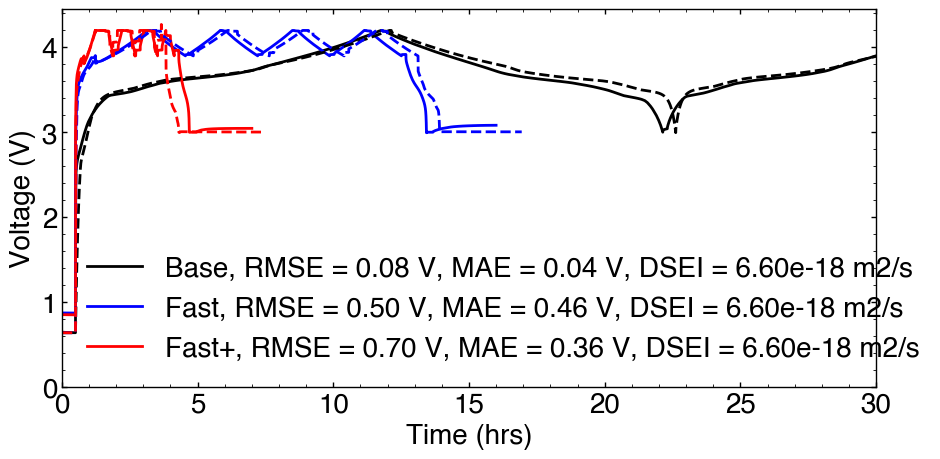

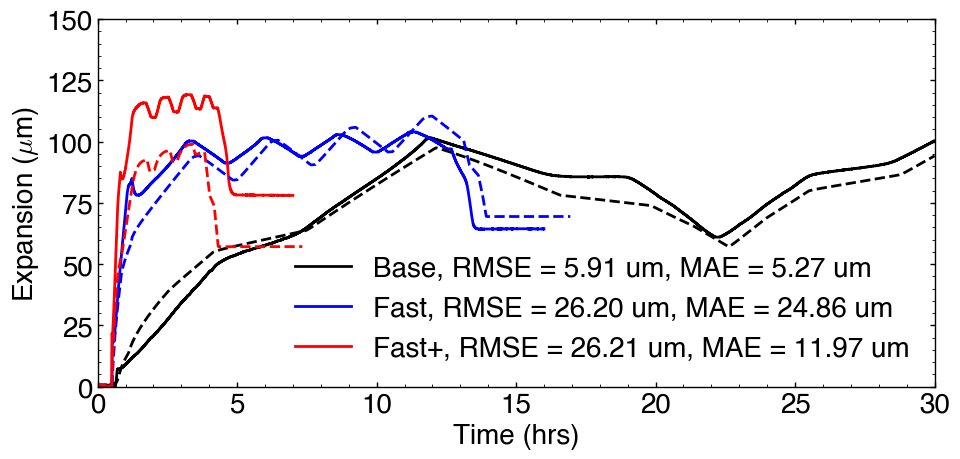

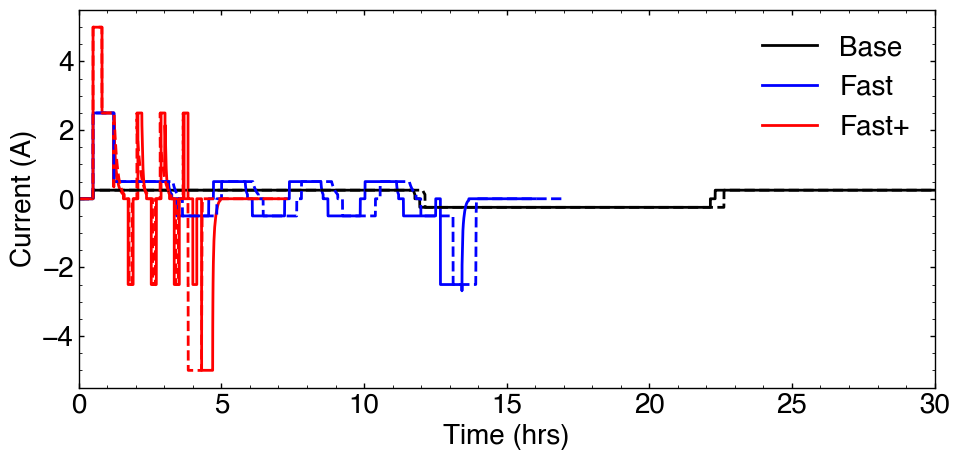

In [42]:
XLIM = (0, 30)

rmse1_v = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
rmse1_e = calculate_rmse(expt1['daq_time'], expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
rmse2_v = calculate_rmse(expt2['arbin_time'], expt2['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
rmse2_e = calculate_rmse(expt2['daq_time'], expt2['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
rmse3_v = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
rmse3_e = calculate_rmse(expt3['daq_time'], expt3['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

mae1_v = calculate_median_error(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
mae1_e = calculate_median_error(expt1['daq_time'], expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
mae2_v = calculate_median_error(expt2['arbin_time'], expt2['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
mae2_e = calculate_median_error(expt2['daq_time'], expt2['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
mae3_v = calculate_median_error(expt3['arbin_time'], expt3['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
mae3_e = calculate_median_error(expt3['daq_time'], expt3['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

# The voltage plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label=f'Base, RMSE = {rmse1_v:.2f} V, MAE = {mae1_v:.2f} V, DSEI = {diff:.2e} m2/s')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label=f'Fast, RMSE = {rmse2_v:.2f} V, MAE = {mae2_v:.2f} V, DSEI = {diff:.2e} m2/s')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label=f'Fast+, RMSE = {rmse3_v:.2f} V, MAE = {mae3_v:.2f} V, DSEI = {diff:.2e} m2/s')
ax.plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['vt'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Voltage (V)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend()
ax.grid(False)

# The expansion plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label=f'Base, RMSE = {rmse1_e:.2f} um, MAE = {mae1_e:.2f} um')
ax.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um, MAE = {mae2_e:.2f} um')
ax.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um, MAE = {mae3_e:.2f} um')
ax.plot(df_sim1['t']/3600, (df_sim1['expansion'])*1e6, color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, (df_sim2['expansion'])*1e6, color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, (df_sim3['expansion'])*1e6, color='r', ls='--', label='')
ax.legend()
ax.set_ylabel(r'Expansion ($\mu$m)')
ax.set_ylim(bottom=0, top=150)
ax.set_xlabel('Time (hrs)')
ax.set_xlim(XLIM)
ax.grid(False)

# The current plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, df_sim1['i_app'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['i_app'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['i_app'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Current (A)')
ax.legend()
ax.grid(False)
ax.set_xlim(XLIM)

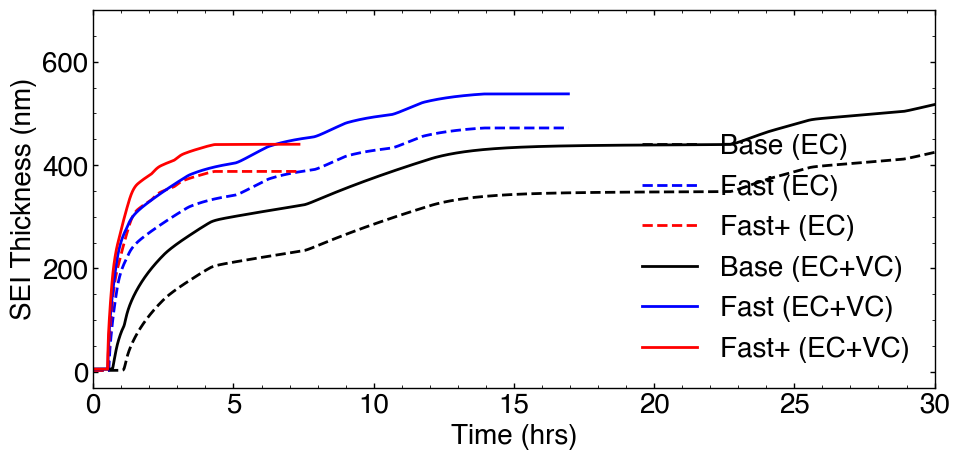

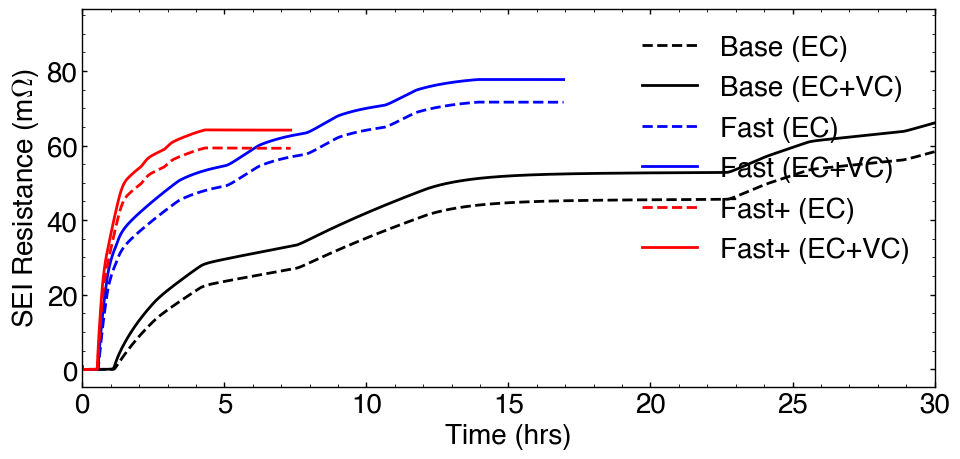

In [13]:
plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['delta_sei1']*1e9, color='k', ls='--', label='Base (EC)')
ax4.plot(df_sim2['t']/3600, df_sim2['delta_sei1']*1e9, ls='--', color='b', label='Fast (EC)')
ax4.plot(df_sim3['t']/3600, df_sim3['delta_sei1']*1e9, ls='--', color='r', label='Fast+ (EC)')
ax4.plot(df_sim1['t']/3600, (df_sim1['delta_sei'])*1e9, color='k', ls='-', label='Base (EC+VC)')
ax4.plot(df_sim2['t']/3600, (df_sim2['delta_sei'])*1e9, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3['t']/3600, (df_sim3['delta_sei'])*1e9, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel('SEI Thickness (nm)')
ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)
ax2 = plt.gca()


plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei1']*1000, color='k', label='Base (EC)', ls='--')
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei']*1000, color='k', label='Base (EC+VC)', ls='-')
ax4.plot(df_sim2['t']/3600, df_sim2['R_sei1']*1000, color='b', ls='--', label='Fast (EC)')
ax4.plot(df_sim2['t']/3600, df_sim2['R_sei']*1000, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3['t']/3600, df_sim3['R_sei1']*1000, color='r', ls='--', label='Fast+ (EC)')
ax4.plot(df_sim3['t']/3600, df_sim3['R_sei']*1000, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel(r'SEI Resistance (m$\Omega$)')

ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)

In [14]:
# Create a table comparing SEI growth across different protocols
df_result = pd.DataFrame()

# Create column headers for different time points
time_points = ['2 hrs', 'After Formation Cycles']

protocols = []
total_sei = []
vc_pcts = []
D_sei1 = []
D_sei2 = []

 # Base formation (sim1)
for t in [2*3600, sim1_time1*3600]:
    q_sei = df_sim1[df_sim1['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim1[df_sim1['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Base')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim1[df_sim1['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim1[df_sim1['t'] <= t]['D_sei2'].iloc[-1])

# Fast formation (sim2)
for t in [2*3600, sim2_time1*3600]:
    q_sei = df_sim2[df_sim2['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim2[df_sim2['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim2[df_sim2['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim2[df_sim2['t'] <= t]['D_sei2'].iloc[-1])

# Fast+ formation (sim3)
for t in [2*3600, sim3_time1*3600]:
    q_sei = df_sim3[df_sim3['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim3[df_sim3['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast+')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim3[df_sim3['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim3[df_sim3['t'] <= t]['D_sei2'].iloc[-1])


df_result = pd.DataFrame({
    'Protocol': protocols,
    'Time Point': time_points * 3,
    'Total SEI (Ah)': total_sei,
    'VC SEI %': vc_pcts,
    'D_sei1': D_sei1,
    'D_sei2': D_sei2
})


print(df_result.to_string(index=False))

Protocol             Time Point  Total SEI (Ah)  VC SEI %       D_sei1       D_sei2
    Base                  2 hrs        0.111791 56.431751 9.561239e-20 9.561239e-20
    Base After Formation Cycles        0.331141 21.279427 5.326165e-20 5.326165e-20
    Fast                  2 hrs        0.165742 26.251272 5.682142e-20 5.682142e-20
    Fast After Formation Cycles        0.263104 18.244011 5.129954e-20 5.129954e-20
   Fast+                  2 hrs        0.186117 19.395429 5.202656e-20 5.202656e-20
   Fast+ After Formation Cycles        0.214427 17.661524 5.093943e-20 5.093943e-20


In [31]:
diff_vec = np.logspace(-20, -15, 50)
rmse1_e_vec = []
rmse1_v_vec = []
rmse2_e_vec = []
rmse2_v_vec = []
rmse3_e_vec = []
rmse3_v_vec = []
mae1_e_vec = []
mae1_v_vec = []
mae2_e_vec = []
mae2_v_vec = []
mae3_e_vec = []
mae3_v_vec = []

for diff in diff_vec:

    print(f'Running simulation with diffusivity {diff:.2e} m2/s')

    df_sim1 = run_sim('base', diff)
    df_sim2 = run_sim('fast', diff)
    df_sim3 = run_sim('fast+', diff)

    rmse1_v = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
    rmse1_e = calculate_rmse(expt1['daq_time'], expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
    rmse2_v = calculate_rmse(expt2['arbin_time'], expt2['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
    rmse2_e = calculate_rmse(expt2['daq_time'], expt2['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
    rmse3_v = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
    rmse3_e = calculate_rmse(expt3['daq_time'], expt3['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

    mae1_v = calculate_median_error(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
    mae1_e = calculate_median_error(expt1['daq_time'], expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
    mae2_v = calculate_median_error(expt2['arbin_time'], expt2['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
    mae2_e = calculate_median_error(expt2['daq_time'], expt2['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
    mae3_v = calculate_median_error(expt3['arbin_time'], expt3['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
    mae3_e = calculate_median_error(expt3['daq_time'], expt3['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

    rmse1_v_vec.append(rmse1_v)
    rmse1_e_vec.append(rmse1_e)
    rmse2_v_vec.append(rmse2_v)
    rmse2_e_vec.append(rmse2_e)
    rmse3_v_vec.append(rmse3_v)
    rmse3_e_vec.append(rmse3_e)

    mae1_v_vec.append(mae1_v)
    mae1_e_vec.append(mae1_e)
    mae2_v_vec.append(mae2_v)
    mae2_e_vec.append(mae2_e)
    mae3_v_vec.append(mae3_v)
    mae3_e_vec.append(mae3_e)

rmse1_e_vec = np.array(rmse1_e_vec)
rmse1_v_vec = np.array(rmse1_v_vec)
rmse2_e_vec = np.array(rmse2_e_vec)
rmse2_v_vec = np.array(rmse2_v_vec)
rmse3_e_vec = np.array(rmse3_e_vec)
rmse3_v_vec = np.array(rmse3_v_vec)

mae1_e_vec = np.array(mae1_e_vec)
mae1_v_vec = np.array(mae1_v_vec)
mae2_e_vec = np.array(mae2_e_vec)
mae2_v_vec = np.array(mae2_v_vec)
mae3_e_vec = np.array(mae3_e_vec)
mae3_v_vec = np.array(mae3_v_vec)


Running simulation with diffusivity 1.00e-20 m2/s
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: 

Optimal VC diffusivity:
Base formation: 1.46e-17 m2/s
Fast formation: 1.68e-19 m2/s
Fast+ formation: 1.00e-15 m2/s


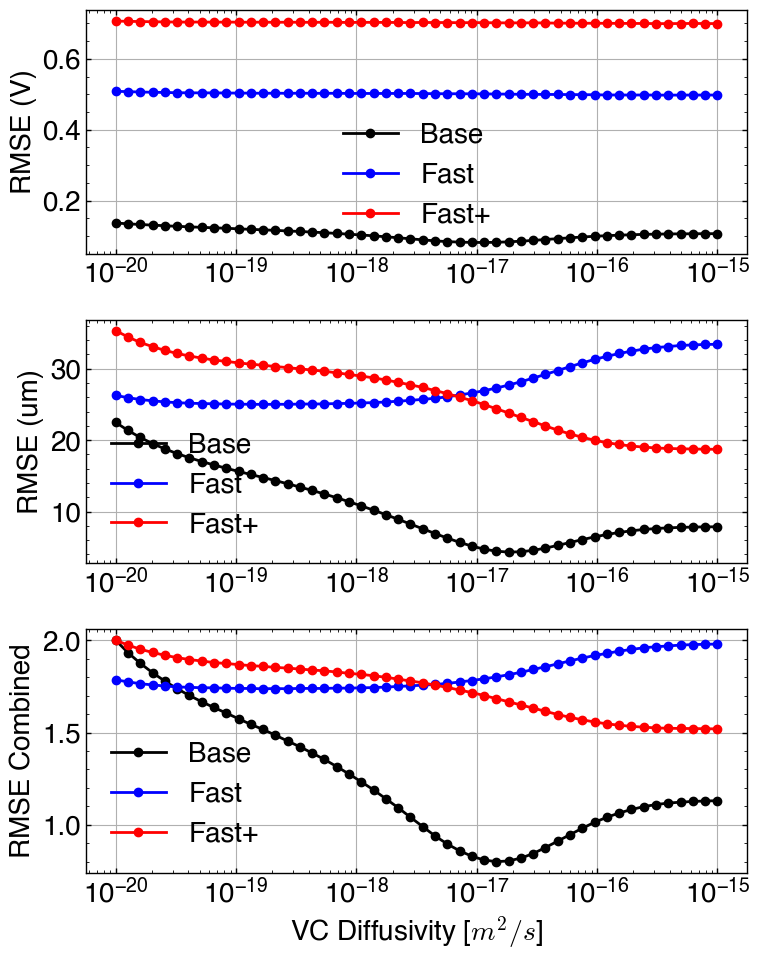

In [32]:
combined_rmse1 = rmse1_e_vec/np.max(rmse1_e_vec) + rmse1_v_vec/np.max(rmse1_v_vec)
combined_rmse2 = rmse2_e_vec/np.max(rmse2_e_vec) + rmse2_v_vec/np.max(rmse2_v_vec)
combined_rmse3 = rmse3_e_vec/np.max(rmse3_e_vec) + rmse3_v_vec/np.max(rmse3_v_vec)

fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(8, 10))

# Plot expansion RMSE
ax1.plot(diff_vec, rmse1_v_vec, c='k', marker='o', label='Base')
ax1.plot(diff_vec, rmse2_v_vec, c='b', marker='o', label='Fast')
ax1.plot(diff_vec, rmse3_v_vec, c='r', marker='o', label='Fast+')
ax1.set_xscale('log')
ax1.set_ylabel('RMSE (V)')
ax1.legend()

# Plot voltage RMSE
ax2.plot(diff_vec, rmse1_e_vec, c='k', marker='o', label='Base')
ax2.plot(diff_vec, rmse2_e_vec, c='b', marker='o', label='Fast')
ax2.plot(diff_vec, rmse3_e_vec, c='r', marker='o', label='Fast+')
ax2.set_xscale('log')
ax2.set_ylabel('RMSE (um)')
ax2.legend()

# Plot combined error
ax3.plot(diff_vec, combined_rmse1, c='k', marker='o', label='Base')
ax3.plot(diff_vec, combined_rmse2, c='b', marker='o', label='Fast')
ax3.plot(diff_vec, combined_rmse3, c='r', marker='o', label='Fast+')
ax3.set_xscale('log')
ax3.set_xlabel('VC Diffusivity [$m^2/s$]')
ax3.set_ylabel('RMSE Combined')
ax3.legend()

# Find minimum of combined error and corresponding diffusivity for each protocol
min_idx1 = np.argmin(combined_rmse1)
min_idx2 = np.argmin(combined_rmse2)
min_idx3 = np.argmin(combined_rmse3)

# Extract the optimal diffusivity values
diff1 = diff_vec[min_idx1]
diff2 = diff_vec[min_idx2]
diff3 = diff_vec[min_idx3]

plt.tight_layout()

print(f"Optimal VC diffusivity:")
print(f"Base formation: {diff1:.2e} m2/s")
print(f"Fast formation: {diff2:.2e} m2/s")
print(f"Fast+ formation: {diff3:.2e} m2/s")

Optimal VC diffusivity:
Base formation: 1.46e-17 m2/s
Fast formation: 1.00e-20 m2/s
Fast+ formation: 1.39e-18 m2/s


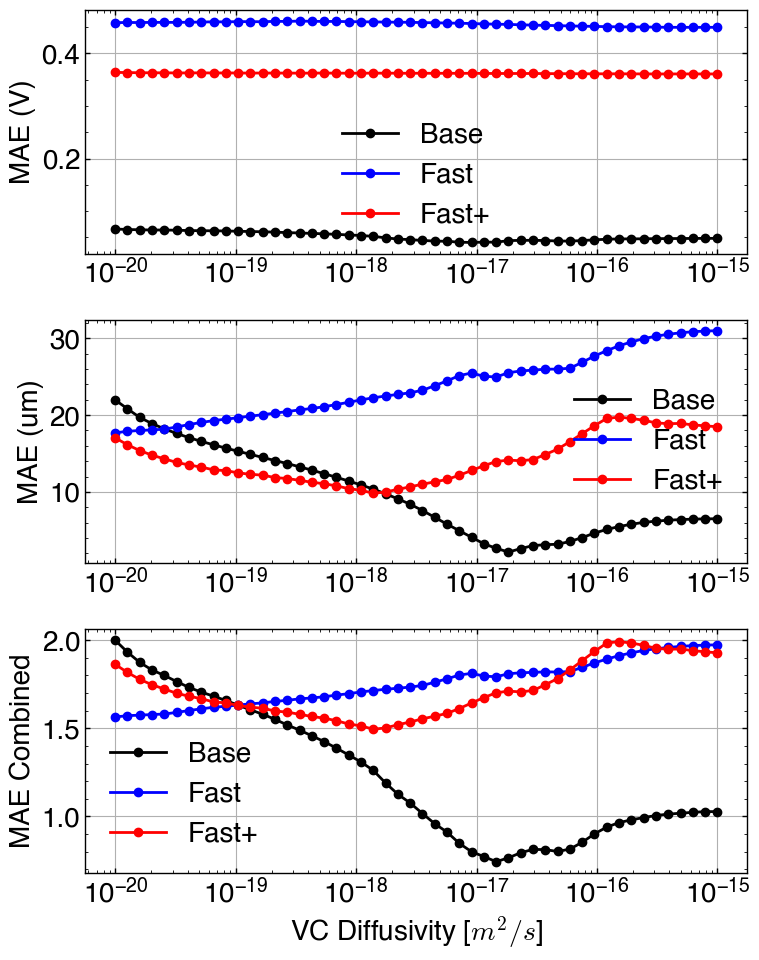

In [34]:
combined_mae1 = mae1_e_vec/np.max(mae1_e_vec) + mae1_v_vec/np.max(mae1_v_vec)
combined_mae2 = mae2_e_vec/np.max(mae2_e_vec) + mae2_v_vec/np.max(mae2_v_vec)
combined_mae3 = mae3_e_vec/np.max(mae3_e_vec) + mae3_v_vec/np.max(mae3_v_vec)

fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(8, 10))

# Plot expansion RMSE
ax1.plot(diff_vec, mae1_v_vec, c='k', marker='o', label='Base')
ax1.plot(diff_vec, mae2_v_vec, c='b', marker='o', label='Fast')
ax1.plot(diff_vec, mae3_v_vec, c='r', marker='o', label='Fast+')
ax1.set_xscale('log')
ax1.set_ylabel('MAE (V)')
ax1.legend()

# Plot voltage RMSE
ax2.plot(diff_vec, mae1_e_vec, c='k', marker='o', label='Base')
ax2.plot(diff_vec, mae2_e_vec, c='b', marker='o', label='Fast')
ax2.plot(diff_vec, mae3_e_vec, c='r', marker='o', label='Fast+')
ax2.set_xscale('log')
ax2.set_ylabel('MAE (um)')
ax2.legend()

# Plot combined error
ax3.plot(diff_vec, combined_mae1, c='k', marker='o', label='Base')
ax3.plot(diff_vec, combined_mae2, c='b', marker='o', label='Fast')
ax3.plot(diff_vec, combined_mae3, c='r', marker='o', label='Fast+')
ax3.set_xscale('log')
ax3.set_xlabel('VC Diffusivity [$m^2/s$]')
ax3.set_ylabel('MAE Combined')
ax3.legend()

plt.tight_layout()

# Find minimum of combined error and corresponding diffusivity for each protocol
min_idx1 = np.argmin(combined_mae1)
min_idx2 = np.argmin(combined_mae2)
min_idx3 = np.argmin(combined_mae3)

print(f"Optimal VC diffusivity:")
print(f"Base formation: {diff_vec[min_idx1]:.2e} m2/s")
print(f"Fast formation: {diff_vec[min_idx2]:.2e} m2/s")
print(f"Fast+ formation: {diff_vec[min_idx3]:.2e} m2/s")

# Re-run the simulations using optimal Dsei

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.

(0.0, 30.0)

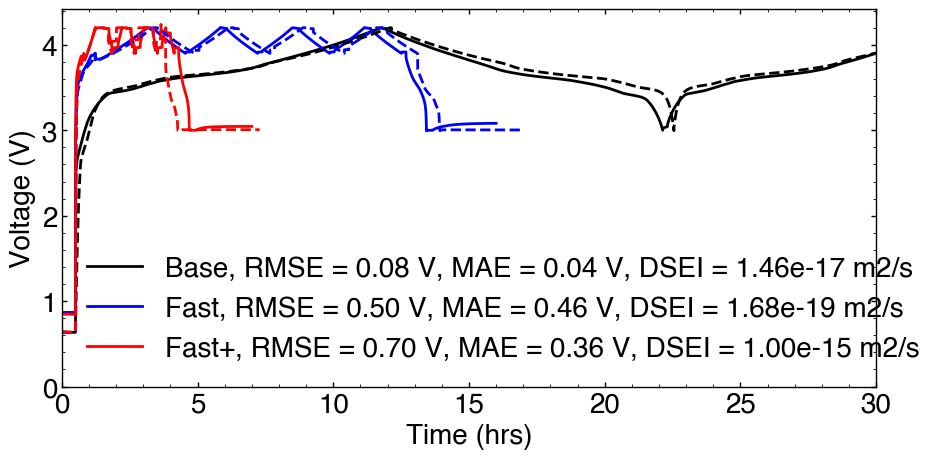

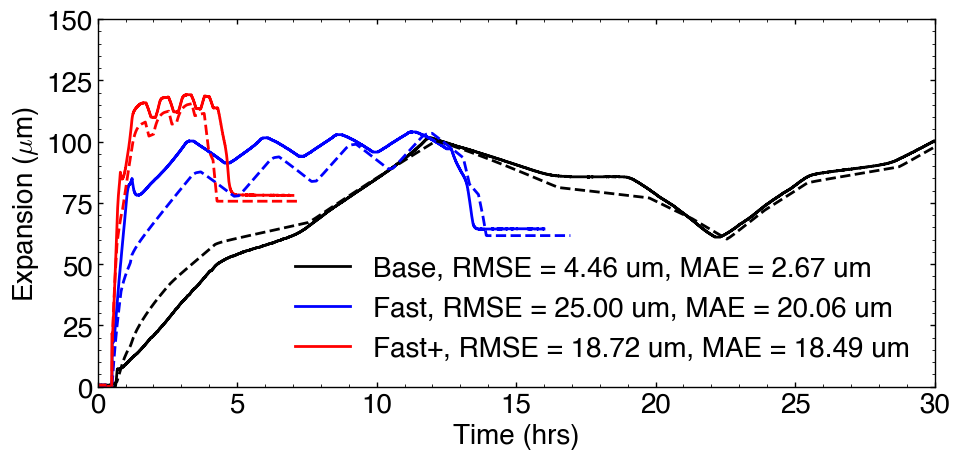

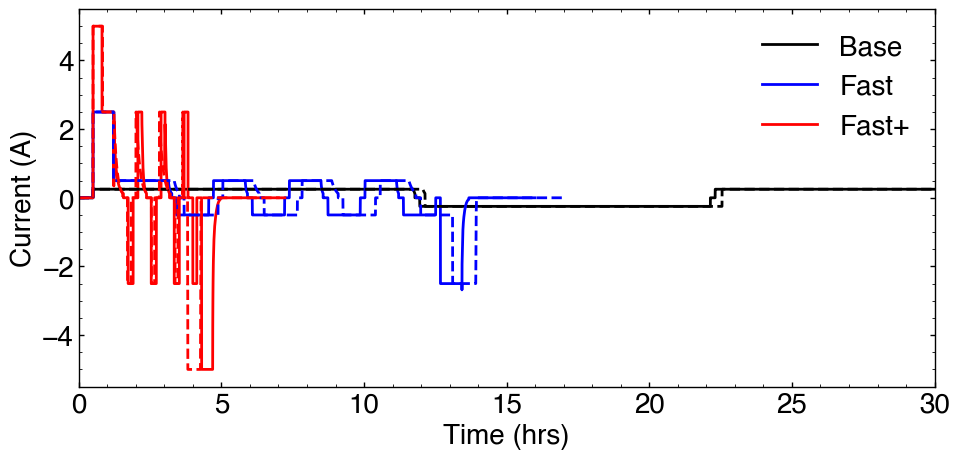

In [35]:
df_sim1 = run_sim('base', diff1)
df_sim2 = run_sim('fast', diff2)
df_sim3 = run_sim('fast+', diff3)

XLIM = (0, 30)

rmse1_v = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
rmse1_e = calculate_rmse(expt1['daq_time'], expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
rmse2_v = calculate_rmse(expt2['arbin_time'], expt2['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
rmse2_e = calculate_rmse(expt2['daq_time'], expt2['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
rmse3_v = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
rmse3_e = calculate_rmse(expt3['daq_time'], expt3['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

mae1_v = calculate_median_error(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
mae1_e = calculate_median_error(expt1['daq_time'], expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
mae2_v = calculate_median_error(expt2['arbin_time'], expt2['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
mae2_e = calculate_median_error(expt2['daq_time'], expt2['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
mae3_v = calculate_median_error(expt3['arbin_time'], expt3['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
mae3_e = calculate_median_error(expt3['daq_time'], expt3['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

# The voltage plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label=f'Base, RMSE = {rmse1_v:.2f} V, MAE = {mae1_v:.2f} V, DSEI = {diff1:.2e} m2/s')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label=f'Fast, RMSE = {rmse2_v:.2f} V, MAE = {mae2_v:.2f} V, DSEI = {diff2:.2e} m2/s')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label=f'Fast+, RMSE = {rmse3_v:.2f} V, MAE = {mae3_v:.2f} V, DSEI = {diff3:.2e} m2/s')
ax.plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['vt'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Voltage (V)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend()
ax.grid(False)

# The expansion plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label=f'Base, RMSE = {rmse1_e:.2f} um, MAE = {mae1_e:.2f} um')
ax.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um, MAE = {mae2_e:.2f} um')
ax.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um, MAE = {mae3_e:.2f} um')
ax.plot(df_sim1['t']/3600, (df_sim1['expansion'])*1e6, color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, (df_sim2['expansion'])*1e6, color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, (df_sim3['expansion'])*1e6, color='r', ls='--', label='')
ax.legend()
ax.set_ylabel(r'Expansion ($\mu$m)')
ax.set_ylim(bottom=0, top=150)
ax.set_xlabel('Time (hrs)')
ax.set_xlim(XLIM)
ax.grid(False)

# The current plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, df_sim1['i_app'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['i_app'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['i_app'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Current (A)')
ax.legend()
ax.grid(False)
ax.set_xlim(XLIM)